# Discovering the menu — every variant, from inside Python

Tengri is plugin-aware. The library knows what physics it ships, which
inference backends are installed and compatible with a given model,
what filters are on disk, and how to fetch missing SSP grids. Asking
Python is faster than reading docs.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import warnings

# Keep the rendered tutorial clean: silence framework notices that do not
# change the science shown here (baked-in nebular, the WavePrecomp blue-band
# approximation, the intentional Fitter(sed_model, ...) LUT path, and
# recipe/parameter-provenance notices). Genuine deprecations in user-facing
# calls are fixed in the code, not hidden.
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*Fitter.*deprecated.*")
warnings.filterwarnings("ignore", message=".*was marked FIXED.*")
warnings.filterwarnings("ignore", message=".*Composable AGN.*")
warnings.filterwarnings("ignore", message=".*before the Big Bang.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import inspect
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    Observation,
    Photometry,
    SEDModel,
    builders,
    citations,
    load_ssp_data,
    plot,
    recipes,
)

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

## Bird's eye

In [2]:
tengri.summary()


tengri — what's available:

  Core classes (the four nouns inference talks to):
    tengri.SEDModel         differentiable SED forward chain
    tengri.ForwardModel     outer shell — owns SED + observation, exposes .predict / .predict_observables
    tengri.Parameters       priors + fixed values
    tengri.Fitter           inference driver

     7  physics components           tengri.list_components()
    13  AGN models                   tengri.list_agn_models()
    21  dust attenuation laws        tengri.list_dust_laws()
     7  dust emission templates      tengri.list_dust_emission_models()
    33  SFH models                   tengri.list_sfh_models()
     5  nebular backends             tengri.list_nebular_backends()
   242  photometric filters          tengri.list_filters()
     8  plotting helpers             tengri.list_plots()
     8  primary inference methods    tengri.list_inference_methods(tier='primary')
    19  total inference methods      tengri.list_inference_methods()



## SSP catalogs

Bare-stellar grids (e.g. `fsps_prsc_miles_chabrier`) pair with the Cue
nebular emulator; "wNE" grids carry baked-in nebular emission and pair
with the `ssp` nebular backend. `download_ssp` fetches missing grids on
demand.

In [3]:
tengri.list_known_ssps()

{'fsps_prsc_miles_chabrier': 'fsps_prsc_miles_chabrier.h5',
 'fsps_mist_c3k_a_chabrier': 'fsps_mist_c3k_a_chabrier.h5',
 'fsps_mist_miles_chabrier': 'fsps_mist_miles_chabrier.h5',
 'fsps_pdva_miles_chabrier': 'fsps_pdva_miles_chabrier.h5',
 'fsps_pdva_c3k_a_chabrier': 'fsps_pdva_c3k_a_chabrier.h5',
 'fsps_bsti_miles_chabrier': 'fsps_bsti_miles_chabrier.h5',
 'fsps_bsti_c3k_a_chabrier': 'fsps_bsti_c3k_a_chabrier.h5',
 'fsps_bsti_basel_chabrier': 'fsps_bsti_basel_chabrier.h5',
 'fsps_mist_basel_chabrier': 'fsps_mist_basel_chabrier.h5',
 'fsps_pdva_basel_chabrier': 'fsps_pdva_basel_chabrier.h5',
 'fsps_prsc_basel_chabrier': 'fsps_prsc_basel_chabrier.h5',
 'fsps_prsc_c3k_a_chabrier': 'fsps_prsc_c3k_a_chabrier.h5',
 'bc03_pdva_stelib_chabrier': 'bc03_pdva_stelib_chabrier.h5',
 'bpss_stars_c3k_a_chabrier': 'bpss_stars_c3k_a_chabrier.h5',
 'pgny_mist_c3k_chabrier': 'pgny_mist_c3k_chabrier.h5',
 'fsps_mist_c3k_a_kroupa': 'fsps_mist_c3k_a_kroupa.h5',
 'fsps_mist_c3k_a_salpeter': 'fsps_mist_c3k_

In [4]:
SSP = Path("../data/fsps_prsc_miles_chabrier.h5")
if not SSP.exists():
    SSP = Path(tengri.download_ssp("fsps_prsc_miles_chabrier"))
ssp = load_ssp_data(str(SSP))

## Star-formation history variants

Each entry of `builders.sfh.available()` is a real callable whose
signature lists its parameters with default priors. Notebook
autocompletion works on it.

In [5]:
builders.sfh.available()

['buat08',
 'burst',
 'bursty_continuity',
 'const',
 'const_exp',
 'continuity',
 'continuity_flex',
 'delayed_bq',
 'dense_basis',
 'dense_basis_pure',
 'dexp',
 'dirichlet',
 'dpl',
 'exp',
 'field',
 'gaussian_burst',
 'lnorm',
 'norm',
 'periodic',
 'prospector_beta',
 'psb',
 'psb_suess2022',
 'snorm',
 'snorm_burst',
 'table',
 'tau',
 'top_hat',
 'tsnorm',
 'tsnorm_burst']

In [6]:
print(inspect.signature(builders.sfh.dpl))

(*, defaults: Any = FIXED, alpha: Any = <object object at 0x11b4afc30>, beta: Any = <object object at 0x11b4afc30>, tau_gyr: Any = <object object at 0x11b4afc30>, log_total_mass: Any = <object object at 0x11b4afc30>) -> dict


Two SFHs at the same mass, side by side:

/Users/suchethacooray/.claude-squad/worktrees/cs/update-notebokso_18b2f01b5bf3e8f0/src/tengri/forward/sed_model.py:997: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


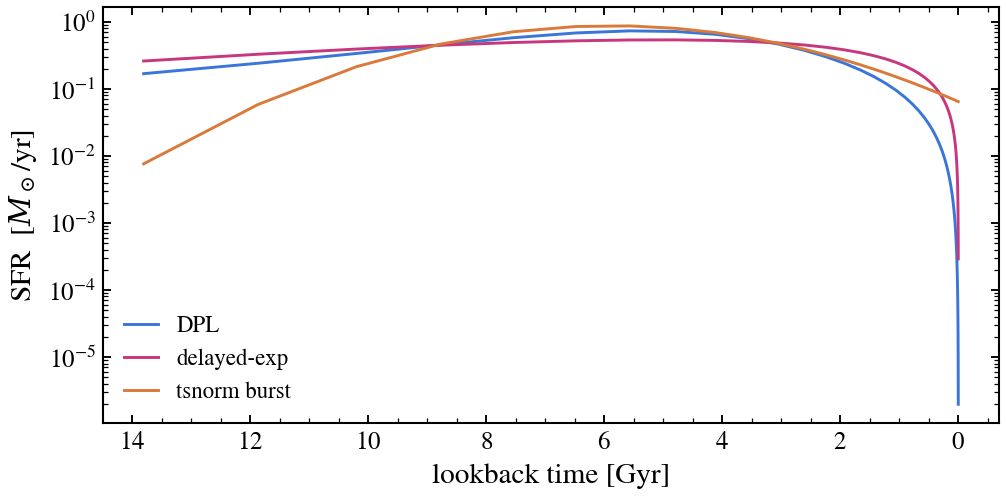

In [7]:
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "wise_w1"])
)


def _build_sfh(sfh_factory):
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        sfh=sfh_factory(defaults=FIXED),
        dust={"type": "two_component", "law_bc": "calzetti", "all_params": FIXED},
        neb={"type": "none"},
        redshift=0.05,
    )


fig, ax = plt.subplots(figsize=(7, 3.6))
for name, factory, color in [
    ("DPL", builders.sfh.dpl, "#3a76d9"),
    ("delayed-exp", builders.sfh.dexp, "#c8377d"),
    ("tsnorm burst", builders.sfh.tsnorm, "#d97a3a"),
]:
    m = _build_sfh(factory)
    p = m.spec.sample(jax.random.PRNGKey(0))
    p = {**m.spec.get_fixed_values(), **p}
    s = m.predict_state(p)
    lbt_gyr = np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9
    sfr = np.asarray(s.derived["sfr_history"])
    ax.plot(lbt_gyr, sfr, color=color, lw=1.4, label=name)
ax.invert_xaxis()
ax.set_xlabel("lookback time [Gyr]")
ax.set_ylabel(r"SFR  [$M_\odot$/yr]")
ax.set_yscale("log")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sfh_variants.png", dpi=300, bbox_inches="tight")

## Dust laws and IR templates

Attenuation laws — Calzetti, Cardelli (MW/LMC/SMC), Prevot SMC, Li 2008,
Witt & Gordon 2000, Conroy/Charlot–Fall variants — and IR re-emission
templates (Dale 2014, Draine–Li, THEMIS, Astrodust, BOSA, Casey 2012,
modified blackbody) all live under `tengri.components.dust`.

In [8]:
tengri.list_dust_laws()

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
cardelli,production,"Cardelli et al. 1989 (ApJ 345, 245) MW extinction",Cardelli et al. MW extinction (parameterized R_V)
conroy2010,production,"Conroy et al. 2010 (ApJ 708, 58)",Conroy+10 mixed MW + power-law (FSPS default)
d03_mwrv31,production,"Draine 2003 (ARA&A 41, 241)",Draine 2003 MW R_V=3.1 grain model attenuation
hd23_mwrv31,production,"Hensley & Draine 2023 (ApJ 948, 55)",Hensley & Draine 2023 astrodust+PAH grain model
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
leitherer02,production,"Leitherer et al. 2002 (ApJS 140, 303)",Leitherer et al. UV starburst attenuation
li08,production,"Li et al. 2008 (ApJ 685, 1046)",Li et al. analytical flexible attenuation curve
lmc,production,"Pei 1992 (ApJ 395, 130) LMC","LMC extinction (Pei 1992, weak bump)"
narayanan_z,production,"Narayanan et al. 2018 (ApJ 869, 70)",Narayanan et al. z-dependent attenuation (SIMBA)


In [9]:
tengri.list_dust_emission_models()

name,status,citation,short_doc
astrodust,experimental,"Hensley & Draine 2023 (ApJ 948, 55)",Astrodust + PAH unified grain model
bosa,experimental,Boquien et al. 2019 (CIGALE BOSA grids),BOSA dust SED templates
dale2014,production,"Dale et al. 2014 (ApJ 784, 83)",SFR-driven empirical IR template family (alpha_sf)
dl07,production,"Draine & Li 2007 (ApJ 657, 810)","Diffuse + PAH grain mixture, Umin/Umax/qpah"
dl14,production,"Draine et al. 2014 (ApJ 780, 172)",Updated DL with extended PAH and silicate features
mbb,production,"Casey 2012 (MNRAS 425, 3094)",Single-temperature modified blackbody (analytic)
themis,experimental,"Jones et al. 2017 (A&A 602, A46)",THEMIS amorphous-carbon grain model


## Nebular backends

- **`cue`** — neural emulator on Cloudy 17.03 (Li+2024). Fast, smooth,
  requires bare-stellar SSP.
- **`ssp`** — baked-in nebular contribution from a wNE SSP grid.
  Cheapest, locked to grid choices.
- **`cloudy`** — direct Cloudy evaluation. Accurate, slow.
- **`none`** — disable.

In [10]:
tengri.list_nebular_backends()

name,status,citation,short_doc
cb19,production,Charlot & Bruzual 2019 / Martinez-Paredes+2023 (3MdB_17),6D CB19 lines-only nebular grid (CB19SEDComponent)
cloudy,production,Byler+2017 / Cloudy grids,Trilinear interp on Cloudy photoionisation grid (CloudyGridBackend)
cue,production,Li et al. 2025 (CUE neural emulator),Neural-network Cloudy emulator with 12 free params (CueBackend)
none,production,,Disable nebular emission (continuum + lines)
ssp,production,DSPS / FSPS SSP-internal,Emission baked into SSP grid; zero free params (BakedInBackend)


## AGN composables

AGN is built from six orthogonal stages — disc, nlr, blr, feii, torus,
attenuation — each with its own registry of swappable blocks. The
composable blocks are the recommended surface for mixing and matching AGN
components. `recipes.agn_panchromatic()` is one stable composition.

In [11]:
tengri.list_agn_models()

name,status,citation,short_doc,param_details
adaf,production,"Mahadevan 1997 (ApJ 477, 585)",ADAF + truncated disc + simple torus (low-luminosity),"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor — DEPRECATED; use agn_frac_agn'}]"
cat3d_wind,production,"Hönig & Kishimoto 2017 (ApJL 838, L20)",Power-law disc + CAT3D-Wind clumpy torus,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor — DEPRECATED; use agn_frac_agn'}]"
composable,production,(no single paper — block recipe of registered tengri AGN blocks),Composable AGN: pick one block per stage (disc/lines/feii/torus/atten),"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}]"
grahsp,production,,,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_grahsp_uvslope', 'default': 'Fixed(0.0)', 'description': 'GRAHSP BBB UV power-law index alpha_1 (paper uvslope). Typical 0; must satisfy uvslope > plslope.'}, {'name': 'agn_grahsp_plslope', 'default': 'Fixed(-1.7)', 'description': 'GRAHSP BBB optical power-law index alpha_2 (paper plslope). Typical -2.7 to -1; must satisfy uvslope > plslope.'}, {'name': 'agn_grahsp_plbendloc_nm', 'default': 'Fixed(100.0)', 'description': 'GRAHSP BBB bend wavelength lambda_break [nm] (paper plbendloc). Typical 50-200 nm.'}, {'name': 'agn_grahsp_plbendwidth', 'default': 'Fixed(1.0)', 'description': 'GRAHSP BBB bend width Lambda [dex] (paper plbendwidth). Typical 0.1-10.'}, {'name': 'agn_grahsp_cutoff_nm', 'default': 'Fixed(10000.0)', 'description': 'GRAHSP BBB IR cutoff [nm]; -1 disables (paper cutoff). Default 1e4.'}, {'name': 'agn_grahsp_a_lines', 'default': 'Fixed(1.0)', 'description': 'GRAHSP line strength scale (paper Alines). Typical 0.3-20.'}, {'name': 'agn_grahsp_a_feii', 'default': 'Fixed(5.0)', 'description': 'GRAHSP FeII forest strength relative to broad H-beta (paper AFeII). Typical 2-10.'}, {'name': 'agn_grahsp_linewidth_kms', 'default': 'Fixed(5000.0)', 'description': 'GRAHSP emission-line FWHM [km/s] (paper Wline). Typical 100-30000.'}, {'name': 'agn_grahsp_fcov', 'default': 'Fixed(0.4)', 'description': 'GRAHSP torus covering factor at 12 um (paper fcov). Typical 0.05-0.95; relates to Stalevski+2016 geometric f_cov.'}, {'name': 'agn_grahsp_si', 'default': 'Fixed(0.0)', 'description': 'GRAHSP Si feature strength (paper Si). Negative=absorption, positive=emission. Typical -4 to +4.'}, {'name': 'agn_grahsp_cool_lam_um', 'default': 'Fixed(17.0)', 'description': 'GRAHSP cool dust peak wavelength [um] (paper COOLlam). Typical 10-30 um.'}, {'name': 'agn_grahsp_cool_width', 'default': 'Fixed(0.45)', 'description': 'GRA

### Composable AGN blocks — discovery and mixing

The composable grammar groups blocks by pipeline stage. Use
`list_agn_blocks()` to see all available options, grouped by category.
Each block has a citation, status, and description accessible via
`describe_agn_block()`.

In [ ]:
tengri.list_agn_blocks()

In [ ]:
# Inspect a specific block
tengri.describe_agn_block("skirtor", category="torus")

## Recipes — five curated starting points

In [12]:
print(list(recipes.__all__))

['agn_panchromatic', 'dust_demo', 'mock_recovery_minimal', 'quiescent_z0', 'star_forming_photometry', 'stochastic_sfh_jwst']


In [13]:
recipes.star_forming_photometry()

{'sfh': {'type': 'dpl', '*': FREE},
 'dust': {'type': 'two_component',
  '*': FREE,
  'law_bc': 'calzetti',
  'law_diff': 'calzetti',
  'emission': {'type': 'dale2014', '*': FIXED}},
 'neb': {'type': 'cue', '*': FIXED},
 'redshift': Uniform(0.01, 6.0),
 'apply_igm': True,
 'approx': WavePrecomp(n_z=100, z_min=None, z_max=None, catalog_z_range=None)}

## Inference backends

The `status` column reports whether each backend's dependencies are
importable. Compatibility against a specific model is rechecked at
`Fitter.run` time.

In [14]:
tengri.list_inference_methods()

name,tier,status,short_doc
laplace,primary,ok,"Laplace approximation around the MAP (cold ~5-9s, warm ~1-2s, ~3 GB)"
map,primary,ok,Adam MAP optimization
mcmc,primary,ok,"Auto MCMC: NUTS for low-D, raytrace for high-D"
mcmc_hmc,primary,ok,"Hamiltonian Monte Carlo (cold ~21s, ~5 GB on D=6-7). Convergence-validated only with dense_mass_matrix=True, n_warmup≥1000, n_leapfrog_steps≥20 on D=6 DPL (R-hat 1.008, ESS 411). Default n_warmup=300 / dense=True gives R-hat ≫ 1 — do not lower the warmup for science."
mcmc_nuts,primary,ok,No-U-Turn Sampler (cold ~90s at D=6 DPL; warmup blows past 5 min on dense_basis D=7 — prefer mcmc_hmc or mcmc_ghmc for dense_basis SFH)
mcmc_raytrace,primary,ok,Ray-tracing ensemble sampler (high-D)
vi,primary,ok,"NIFTy geoVI variational inference (cold ~100s, ~20 GB RSS at D=6-7 — memory-heavy; consider mcmc_ghmc for faster turnaround on D<10)"
vi_nonlinear_fast,primary,ok,NIFTy geoVI without Python logging
mcmc_adjusted_mclmc,experimental,ok,"Adjusted microcanonical Langevin (cold ~60s, ~3x compile premium over mclmc)"
mcmc_dynamic_hmc,experimental,ok,"Dynamic HMC — fast (cold ~19s) but chains under-mix at default settings (R-hat ≈ 1.11-1.25, ESS ≈ 1-30 on D=6-7 mocks, 1000 warmup + 2000 samples). Needs tuning before science use."


## Parameter and physics provenance

Two introspection surfaces close the loop:
`model.spec.summary()` tags every parameter with where its value came
from (`[user]` / `[all_params FREE]` / `[all_params FIXED]` / `[default]`).
`citations.collect_citations(model)` returns the bibliography of every
physics ingredient.

In [15]:
example = SEDModel.build(ssp_data=ssp, observation=obs, **recipes.star_forming_photometry())
example.spec.summary()

/Users/suchethacooray/.claude-squad/worktrees/cs/update-notebokso_18b2f01b5bf3e8f0/src/tengri/components/nebular/ionizing_spectrum.py:96: RuntimeWarning: invalid value encountered in scalar divide
  np.abs((_seg_wave[-1] ** params[0] - _seg_wave[0] ** params[0]) / params[0])


Parameters  SFH: dpl
──────────────────────────────────────────────────────────────────
  Dimensions:  8 free, + 29 fixed
  Modules:     nebular=cue, dust_emission=dale2014, igm, dust_law=calzetti/calzetti

  Parameter                        Prior                      Bounds                 Source
  ──────────────────────────────────────────────────────────────────────────────────────────
  dust_tau_bc                      Uniform(0.0, 4.0)          [0, 4]                 [* FREE]
  dust_tau_diff                    Uniform(0.0, 3.0)          [0, 3]                 [* FREE]
  met_logzsol                      Uniform(-2.0, 0.2)         [-2, 0.2]              [* FREE]
  redshift                         Uniform(0.01, 6.0)         [0.01, 6]              [user]
  sfh_dpl_alpha                    Uniform(0.1, 5.0)          [0.1, 5]               [* FREE]
  sfh_dpl_beta                     Uniform(0.1, 3.0)          [0.1, 3]               [* FREE]
  sfh_dpl_log_total_mass           Uniform(7.0

In [16]:
bib = citations.collect_citations(example)
citations.print_citations(example)

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Carnall et al. (2018)  —  Reference SED fitting framework (BAGPIPES)
       {Inferring the star formation histories of massive quiescent galaxies with BAGPIPES: evidence for multiple quenching mechanisms}
       DOI: 10.1093/mnras/sty2169   arXiv: 1712.04452   code: ACCarnall/bagpipes

  [5] Dale

Export to BibTeX in one call:

In [17]:
bibtex = citations.citations_bibtex(example)
print(bibtex[:600], "…")

@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

@article{Jamesbradbury_2018,
  author = {James Bradbury and Roy Frostig and Peter Hawkins and Matthew James Johnson and Chris Leary and Dougal Maclaurin and George Necula and Adam Paszke and Jake Vander{P}las and Skye Wanderman-{M}ilne and Qiao Zhang},
  title = {{JAX}: composable transformations of {P}ython+{N}um{P}y programs},
  year = {2018},
}

@a …


## Cache and memory

- **`tengri.lean`** — context manager / default mode. Drops the
  per-Fitter JIT engine after each `run` to release graph memory.
- **`tengri.persistent`** — opposite mode. Keep the engine for
  repeated same-shape fits (population sweep, MCMC restart).
- **`tengri.gc`** — one-shot collect: clears shared caches and asks
  XLA to release the device.
- **`tengri.clear_shared_caches()`** — full reset for clean
  benchmarking.

The persistent JAX compile cache (`~/.cache/tengri_jax_cache`,
auto-enabled by `import tengri`) is independent of these — it survives
process restarts.

## Cross-namespace search

`tengri.search("term")` queries every registry at once.

In [18]:
tengri.search("Calzetti")

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
noll09,production,"Noll et al. 2009 (A&A 507, 1793)",Noll et al. modified Calzetti + L02 + bump + slope
salim,production,"Salim et al. 2018 (ApJ 859, 11)",Salim et al. modified Calzetti (DSPS default)
salim_sbl18,production,"Salim et al. 2018 (ApJ 859, 11)","Salim, Boquien & Lee modified Calzetti + L02"


## Sub-namespaces — where to look for what

- **`tengri.cosmology`** — Planck 2018 distance and time integrals
  (`luminosity_distance_mpc`, `age_at_z`, …).
- **`tengri.units`** — F_ν ↔ L_ν ↔ AB-mag conversions, vacuum-air, Jy.
- **`tengri.plot`** — `plot_sed_fit`, `plot_sfh`, `plot_corner_comparison`,
  `setup_style`, `diagnostics_table`. Re-exports of
  `tengri.analysis.plotting`.
- **`tengri.observation`** — `Photometry`, `Spectroscopy`, `Observation`,
  `NoiseModel`, `LineList`, filter loaders.
- **`tengri.inference`** — `Fitter`, `CatalogFitter`, `PopulationFitter`,
  `VIConfig`, `InferenceContext`.
- **`tengri.results`** — `Posterior`, `CatalogPosterior`,
  `PopulationPosterior`, `FitResult`, `MockData`, `Provenance`,
  `generate_mock`.
- **`tengri.config`** — `SEDModelConfig`, `SFHConfig`, `DustConfig`,
  `NebularConfig`, `AGNConfig`.
- **`tengri.protocols`** — Protocol shapes (`SEDComponent`, `Likelihood`,
  `ObservationModel`, `DerivedKey`, `ForwardState`).
- **`tengri.builders`** — config-dict factories with introspectable
  signatures (`builders.sfh.*`, `builders.dust.*`, `builders.neb.*`,
  `builders.agn.*`, `builders.igm.*`).
- **`tengri.citations`** — `Bibliography`, `Citation`,
  `collect_citations`, `citations_report`, `citations_bibtex`,
  `print_citations`, `print_bibtex`, `paper_citation`.

From here: try `tengri.help()` for topic-indexed pointers, or
`dir(tengri.components.<area>)` for any physics sub-namespace.